# Определение стоимости недвижимости из набора данных California Housing

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".


## Подготовка данных для обучения сети


**Загружаем набор данных**

Набор данных California Housing доступен через библиотеку scikit-learn. Разделим его на обучающий и тестовый наборы.


In [36]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


In [122]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

In [131]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [140]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

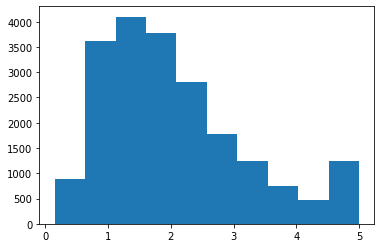

In [141]:
plt.hist(y);

In [142]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [75]:
y.min(), y.max()

(0.14999, 5.00001)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Обучающий набор: {X_train.shape}, {y_train.shape}")
print(f"Тестовый набор: {X_test.shape}, {y_test.shape}")

Обучающий набор: (15480, 8), (15480,)
Тестовый набор: (5160, 8), (5160,)


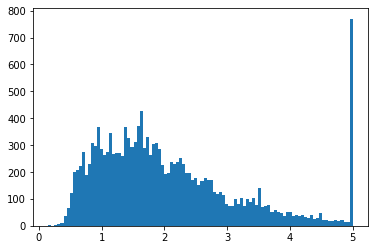

In [77]:
plt.hist(y_train,100);

**Размерность данных**


In [78]:
X_train.shape, y_train.shape


((15480, 8), (15480,))

Просматриваем данные


In [65]:
y_train[:5]


array([2.285, 2.799, 1.83 , 4.658, 1.5  ])

**Названия столбцов**

- MedInc: median income in block group
- HouseAge: median house age in block group
- AveRooms: average number of rooms per household
- AveBedrms: average number of bedrooms per household
- Population: block group population
- AveOccup: average number of household members
- Latitude: block group latitude
- Longitude: block group longitude

Целевая переменная - средняя стоимость недвижимости в квартале (в сотнях тысяч долларов).


**Предварительная обработка данных**


Нормализация данных для обучения


In [143]:
# Нормализация данных
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std
X_test

array([[-1.15411223, -0.28514924, -0.51346718, ...,  0.06447083,
         0.19367548,  0.28652736],
       [-0.70756701,  0.11133247, -0.16361884, ..., -0.03570466,
        -0.23746391,  0.06179445],
       [-0.20917611,  1.855852  , -0.6022714 , ..., -0.14606959,
         1.00909127, -1.4264368 ],
       ...,
       [-0.89908611,  0.66640687, -0.89340574, ...,  0.12360294,
        -0.76232924,  0.66108221],
       [ 1.58036659, -1.79177974,  0.80393479, ..., -0.04836253,
         1.34181841, -0.73725589],
       [ 1.44652384,  0.58711053,  0.12349223, ..., -0.04755791,
        -0.82325111,  0.5911653 ]])

Масштабирование целевой переменной

Целевая переменная выражена в сотнях тысяч долларов. Для удобства разделим её на 100000, чтобы значения были того же порядка, что и признаки.


In [144]:
# y_train = y_train / 100000
# y_test = y_test / 100000
# y_train[:5]

**Создаем тензоры и загрузчики данных**


In [145]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


In [146]:
X_train_t.shape, y_train_t.shape


(torch.Size([15480, 8]), torch.Size([15480]))

In [147]:
batch_size = 32

# Для регрессии используем собственный набор данных
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Для проверочного набора выделим 20% обучающего
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [148]:
X_train_t.shape

torch.Size([15480, 8])

## Создаем модель


In [149]:
class RegressionNet(nn.Module):
    def __init__(self, n_features=8):
        super().__init__()
        # Входной слой + скрытый слой + выходной слой
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),  # Входной слой
            nn.ReLU(),
            nn.Linear(64, 32),          # Скрытый слой
            nn.ReLU(),
            nn.Linear(32, 1),           # Выходной слой, без функции активации
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [150]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")
model = RegressionNet().to(device)
print(model)


Используем устройство: cpu
RegressionNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


**Задаем функцию ошибки и оптимизатор**

Для задачи регрессии используется среднеквадратичная ошибка `nn.MSELoss()`.


In [151]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Обучаем модель


In [152]:
def train_reg(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    train_loss, train_mae = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X.size(0)
        train_mae += torch.abs(pred - y).sum().item()
    return train_loss / size, train_mae / size

In [153]:
def test_reg(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    model.eval()
    test_loss, test_mae = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item() * X.size(0)
            test_mae += torch.abs(pred - y).sum().item()
    return test_loss / size, test_mae / size


**Обучаем модель**


In [112]:
epochs = 130
history_train_mae, history_val_mae = [], []
history_train_loss, history_val_loss = [], []

for t in range(epochs):
    tr_loss, tr_mae = train_reg(train_loader, model, loss_fn, optimizer)
    val_loss, val_mae = test_reg(val_loader, model, loss_fn)
    history_train_mae.append(tr_mae)
    history_val_mae.append(val_mae)
    history_train_loss.append(tr_loss)
    history_val_loss.append(val_loss)
    if (t + 1) % 10 == 0:
        print(f"Эпоха {t+1:>3}/{epochs} \tОшибка: {tr_loss:>8f} \tMAE: {tr_mae*100000:>8.0f} \tВал. MAE: {val_mae*100000:>8.0f}")


Эпоха  10/130 	Ошибка: 0.220157 	MAE:    32288 	Вал. MAE:    35701
Эпоха  20/130 	Ошибка: 0.218214 	MAE:    32270 	Вал. MAE:    34869
Эпоха  30/130 	Ошибка: 0.215804 	MAE:    32054 	Вал. MAE:    35771
Эпоха  40/130 	Ошибка: 0.212119 	MAE:    31912 	Вал. MAE:    34758
Эпоха  50/130 	Ошибка: 0.209944 	MAE:    31725 	Вал. MAE:    35382
Эпоха  60/130 	Ошибка: 0.206631 	MAE:    31412 	Вал. MAE:    34747
Эпоха  70/130 	Ошибка: 0.207732 	MAE:    31604 	Вал. MAE:    36629
Эпоха  80/130 	Ошибка: 0.202226 	MAE:    31059 	Вал. MAE:    35946
Эпоха  90/130 	Ошибка: 0.200734 	MAE:    30989 	Вал. MAE:    35963
Эпоха 100/130 	Ошибка: 0.200381 	MAE:    31149 	Вал. MAE:    35126
Эпоха 110/130 	Ошибка: 0.197151 	MAE:    30736 	Вал. MAE:    35271
Эпоха 120/130 	Ошибка: 0.194779 	MAE:    30658 	Вал. MAE:    35068
Эпоха 130/130 	Ошибка: 0.191417 	MAE:    30493 	Вал. MAE:    34980


### Визуализация прогресса обучения


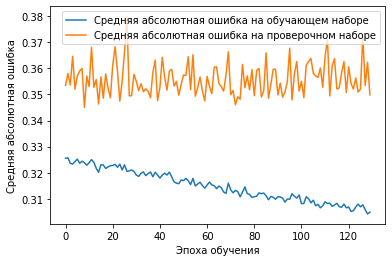

In [154]:
plt.plot(history_train_mae, label='Средняя абсолютная ошибка на обучающем наборе')
plt.plot(history_val_mae, label='Средняя абсолютная ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Средняя абсолютная ошибка')
plt.legend()
plt.show()

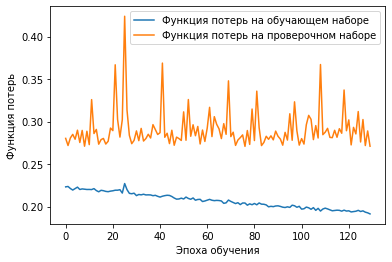

In [114]:
plt.plot(history_train_loss, label='Функция потерь на обучающем наборе')
plt.plot(history_val_loss, label='Функция потерь на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Функция потерь')
plt.legend()
plt.show()

## Оценка качества обучения


Проверка качества работы на наборе данных для тестирования


In [115]:
test_loss, test_mae = test_reg(test_loader, model, loss_fn)
print(f"Средняя абсолютная ошибка на тестовых данных: {test_mae} долларов")

Средняя абсолютная ошибка на тестовых данных: 0.3452954677186271 долларов


## Предсказание на тестовых данных


In [116]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t.to(device))
predictions = predictions.cpu().numpy()
predictions[:5]


array([0.5322954 , 0.70151013, 5.081581  , 2.3843782 , 2.6306453 ],
      dtype=float32)

In [117]:
predictions.min(), predictions.max()

(0.08949396, 6.1683073)

In [118]:
y_test[:10]


array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [119]:
predictions

array([0.5322954 , 0.70151013, 5.081581  , ..., 1.4592762 , 2.9458346 ,
       4.2317586 ], dtype=float32)

In [120]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 1.177  , 2.631  , 4.815  ])

In [121]:
y_test.min(), y_test.max()

(0.14999, 5.00001)